In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

import warnings as wr
wr.filterwarnings('ignore')

### ***Generate imbalanced dataset***

***Synthetic dataset generate করা হচ্ছে make_blobs() ব্যবহার করে।***  
  
***এখানে দুইটা class আছে।***   
***Class 0 → 25 samples***  
***Class 1 → 375 samples***  

***Class 0 → center at (0,0)***   
***Class 1 → center at (2,2)***   
***মানে data points এই center এর আশেপাশে generate হবে।***   

***Standard Deviation determine করে data points center থেকে কতটা ছড়িয়ে থাকবে।***   
***std বেশি হলে points বেশি spread হবে***   
***std কম হলে cluster tight হবে***   
***এখানে দুইটা cluster এর spread 1.5।***   

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate imbalanced dataset
n_samples_1 = 25  # Number of samples in class 1
n_samples_2 = 375  # Number of samples in class 2
centers = [(0, 0), (2, 2)]  # Centers of each cluster
cluster_std = [1.5, 1.5]  # Standard deviation of each cluster

X, y = make_blobs(n_samples=[n_samples_1, n_samples_2],
                centers=centers,
                cluster_std=cluster_std,
                random_state=0)

### ***Plotting Data Points***

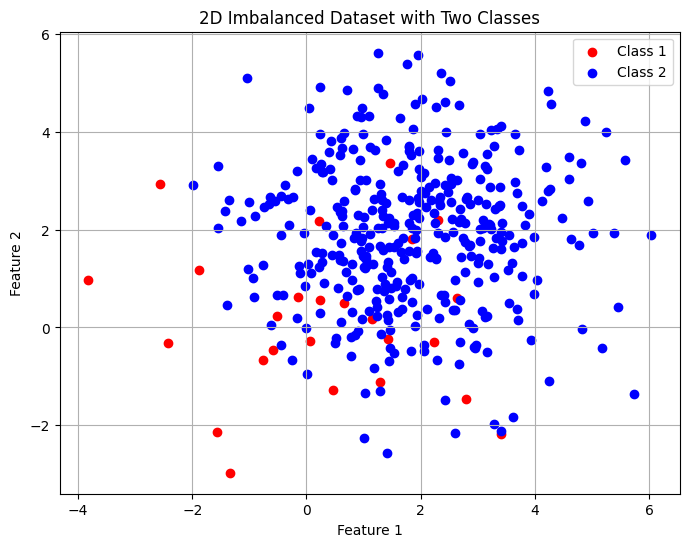

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 2')

plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()
plt.grid(True)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [6]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.96      0.99      0.97        76

    accuracy                           0.95        80
   macro avg       0.73      0.62      0.65        80
weighted avg       0.94      0.95      0.94        80

ROC AUC Score: 0.9473684210526316


### ***Plotting ROC AUC Curve***

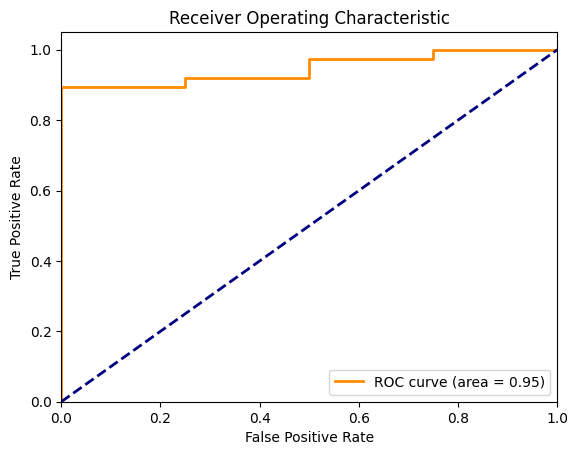

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### ***Ploting Decision Boundaries***

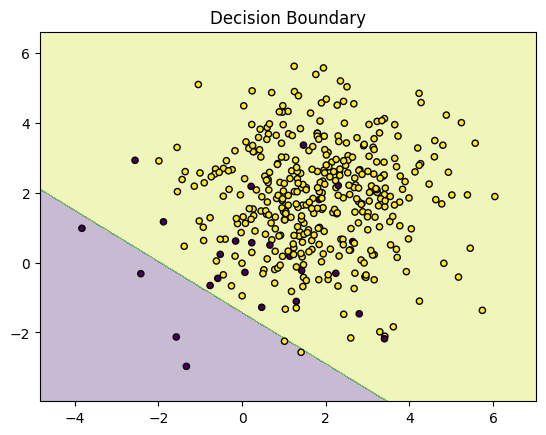

In [8]:
plot_step = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                    np.arange(y_min, y_max, plot_step))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
plt.title("Decision Boundary")
plt.show()

### ***Applying SMOTE***

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### ***Ploting Resampled Data Points***

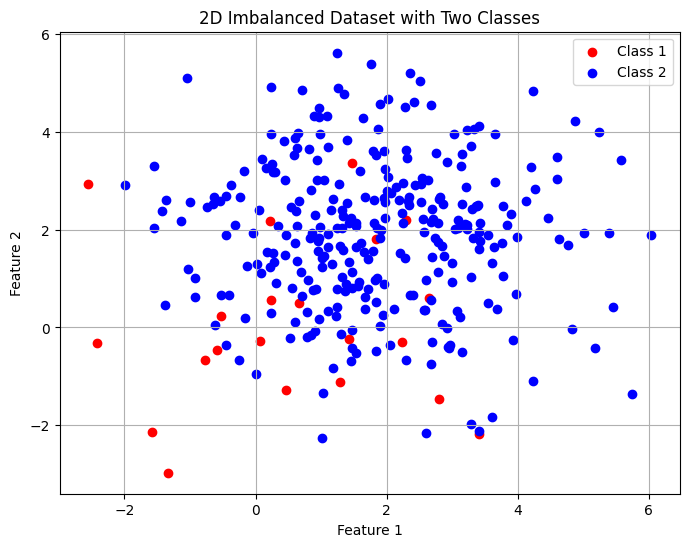

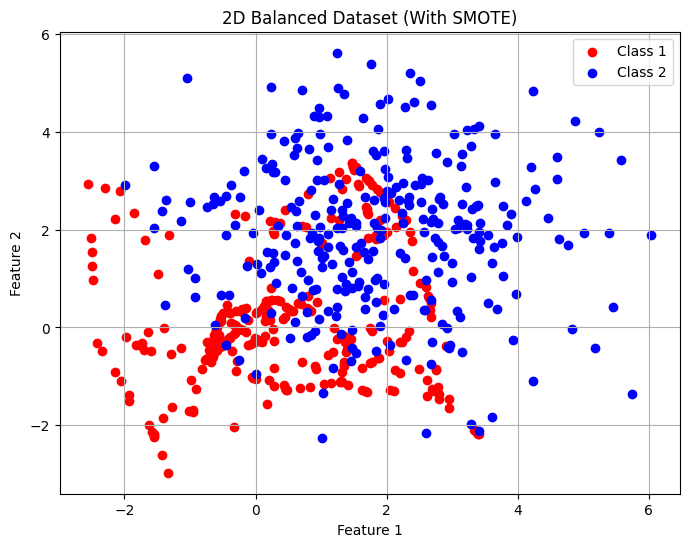

In [10]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled[y_resampled == 0][:, 0], X_resampled[y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled[y_resampled == 1][:, 0], X_resampled[y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Balanced Dataset (With SMOTE)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
resampled_model = LogisticRegression()
resampled_model.fit(X_resampled, y_resampled)

# Predict test set
y_resampled_pred = resampled_model.predict(X_test)
y_resampled_proba = resampled_model.predict_proba(X_test)[:, 1]

In [16]:
# Print classification report
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_resampled_pred))

# Print ROC AUC Score
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_resampled_proba))

Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80

ROC AUC Score (With SMOTE): 0.950657894736842


### ***Plotting ROC AUC Curve (With SMOTE)***

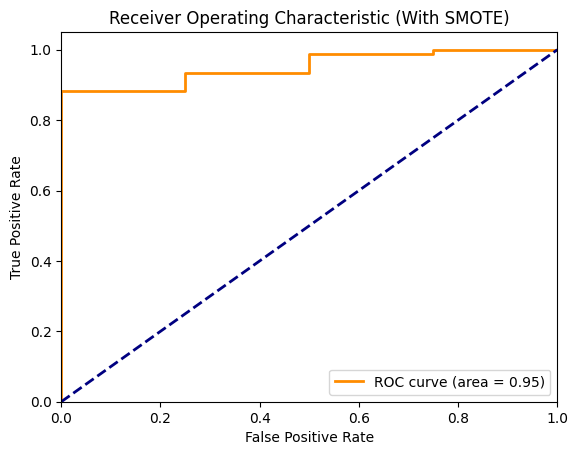

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_resampled_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_resampled_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

### ***Ploting Decision Boundaries (With SMOTE)***

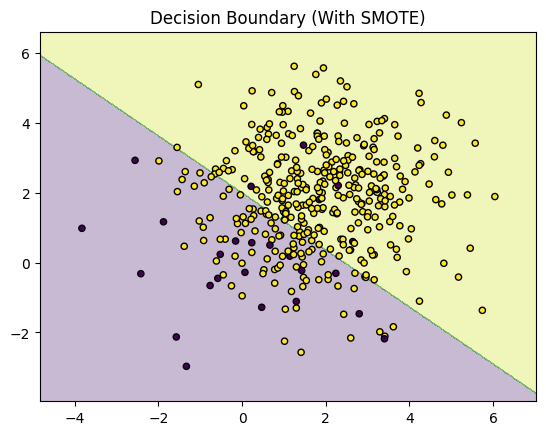

In [18]:
plot_step = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                    np.arange(y_min, y_max, plot_step))
Z = resampled_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
plt.title("Decision Boundary (With SMOTE)")
plt.show()

In [19]:
pd.Series(y).value_counts()

1    375
0     25
Name: count, dtype: int64

In [20]:
pd.Series(y_resampled).value_counts()

1    299
0    299
Name: count, dtype: int64

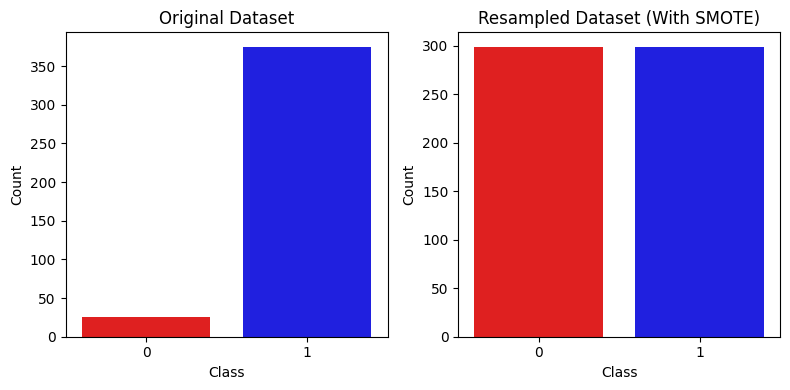

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

# Original Dataset Count Plot
df_orig = pd.DataFrame({'Class': y})
sns.countplot(x='Class', data=df_orig, palette=['red','blue'], ax=axes[0])
axes[0].set_title("Original Dataset")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Resampled Dataset Count Plot
df_resampled = pd.DataFrame({'Class': y_resampled})
sns.countplot(x='Class', data=df_resampled, palette=['red','blue'], ax=axes[1])
axes[1].set_title("Resampled Dataset (With SMOTE)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()